In [1]:
pip install tf-models-official==2.11.3

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 46.3 MB/s eta 0:00:0000:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 352.1/352.1 kB 28.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 636.6/636.6 kB 43.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.6/240.6 kB 24.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 11.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 kB 7.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 28.4 MB/s eta 0:00:00:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 238.9/238.9 kB 23.1 MB/s eta 0:00:00
  Created wheel for pycocotools: filename=pycocotools-2.0.6-cp37-cp37m-linux_x86_64.whl si

In [2]:
!pip install pipreqs

In [3]:
pip install imutils

In [4]:
!pip install wandb --upgrade

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 48.0 MB/s eta 0:00:0000:01
  Attempting uninstall: wandb
    Found existing installation: wandb 0.14.0
    Uninstalling wandb-0.14.0:
      Successfully uninstalled wandb-0.14.0


# Import Packages

In [6]:
import os
import sys
import math
import random
import gc
import numpy as np
from scipy import stats

import cv2
# import imutils

from matplotlib import pyplot as plt
%matplotlib inline
from matplotlib import rcParams
import seaborn as sns
from PIL import Image
# from imageio import imwrite
# from tqdm import tqdm
import seaborn as sns
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
import tensorflow_models as tfm
import tensorflow_probability as tfp

from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.applications import (
    InceptionResNetV2,
    ResNet50,
)
from tensorflow.keras.layers import Input, Dense, Dropout, Flatten, GlobalAveragePooling1D, GlobalAveragePooling2D, LeakyReLU, BatchNormalization
from tensorflow.keras.losses import BinaryCrossentropy, categorical_crossentropy
from tensorflow.keras.callbacks import ModelCheckpoint, Callback, CSVLogger, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam, SGD, RMSprop, Adamax
from tensorflow.keras.applications.imagenet_utils import preprocess_input
# from tensorflow.keras.callbacks import TensorBoard
from tensorflow.keras.metrics import Accuracy, CategoricalAccuracy, Precision, Recall, AUC, TopKCategoricalAccuracy, TruePositives, FalsePositives, TrueNegatives, FalseNegatives
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score 

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical



Imported


# File Links

In [8]:


path = '/kaggle/input/dataset-2-v01/RAW Dataset 2'

model_dir = '/kaggle/input/radimagenet-irv2/RadImageNet-IRV2_notop.h5'

CODE_OUTPUTS = '/kaggle/working/'
csv_logger = CSVLogger(f'{CODE_OUTPUTS}training.log')

# Helper Functions

In [10]:
def display_images(images, name):
#     Display 9 Images
    for i in range(9):
        # define subplot
        plt.subplot(3, 3, 1 + i)
        plt.axis("off")
        # plot single image
        image = images[i+9, :, :, 0]
        plt.imshow(image, cmap="gray")
        plt.savefig(
            f'{CODE_OUTPUTS}{name}image.jpg',
            dpi=300,
            transparent=True,
        )
    plt.show()
    plt.close()
    
def visualize_distribution(images1, images2, count):
    fig, axs = plt.subplots(ncols=1, nrows=1, figsize=(18, 10))

    images1 = images1[:count]
    sns.distplot(images1, label="Real Images", hist=True, color="#fc0328", ax=axs)
    if images2 != None:
        images2 = images2[:count]
        sns.distplot(images2, label="Generated Images", hist=True, color="#0c06c7", ax=axs)
    axs.legend(loc="upper right", prop={"size": 12})
    pyplot.savefig(
        distribution,
        bbox_inches="tight",
        transparent=True,
    )
    plt.show()
    plt.close()

def visualize_class_distribution(classes, name):
    fig, axs = plt.subplots(ncols=1, nrows=1, figsize=(18, 10))
    sns.distplot(classes, label= name, hist=True, color="#fc0328", ax=axs)
    plt.savefig(
        f"class_distribution_{name}.jpg",
        bbox_inches="tight",
        transparent=True,
        dpi= 300,
    )
    plt.show()
    plt.close()
    
def bytes_to_megabytes(bytes):
    megabytes = bytes / (1024 * 1024)
    return megabytes


# Variables Setup

In [11]:

LATENT_DIM = 100
DISPLAY_GENRATED_SAMPLES = 10
BATCH_SIZE = 16
IMAGE_SIZE = 128

TRAIN_RATIO = 0.80 # 70
VALIDATION_RATIO = 0.10 # 30
TEST_RATIO = 0.10

CLASSIC_AUG = True
GAN_AUG = False
MIXUP_AUG = True




Before defining variables:


# Preprocessing & Enhancement

In [12]:
def Enhancement(image):
    
    NOISE_FLOOR = 20

    def reduce_noise(noisy_img, noise_floor=NOISE_FLOOR):

        clean_img = noisy_img
        clean_img[noisy_img < NOISE_FLOOR] = 0
        return clean_img

    def eualize_darken(image):        
        new_img = cv2.bilateralFilter(image,1,10,10)
        img_hsv = cv2.cvtColor(new_img, cv2.COLOR_RGB2YCrCb)
        img_hsv[:, :, 0] = cv2.equalizeHist(img_hsv[:, :, 0])
        image = cv2.cvtColor(img_hsv, cv2.COLOR_YCrCb2RGB)  
        return image

    def gammaCorrection(src, gamma):
        image = src.astype(np.float32) / 255.0
        gamma_corrected = np.power(image, gamma)

        # Convert the gamma-corrected image back to uint8
        image = (gamma_corrected * 255).clip(0, 255).astype(np.uint8)
        return image
    image = reduce_noise(image)
    image = eualize_darken(image)
    image = gammaCorrection(image, 1.6)

    return image

# Import Data

There are 926 samples in the class glioma_tumor
There are 937 samples in the class meningioma_tumor
There are 901 samples in the class pituitary_tumor
Images:  (2764, 128, 128, 3)
Labels:  (2764,)
Images size:129.5626449584961, labels: 0.02118682861328125 


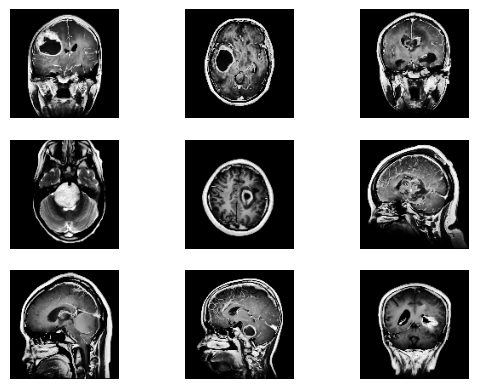

In [13]:
Images = []
Labels = []
Classes = ['glioma_tumor', 'meningioma_tumor', 'pituitary_tumor']
classes_dict = {'glioma_tumor': 0, 'meningioma_tumor':1, 'pituitary_tumor':2}

for Class in classes_dict.keys():
    class_samples = 0
    cpath = os.path.join(path, Class)
    cpath += '/'

    for img in os.listdir(cpath):
        class_samples += 1

        image = cv2.imread(os.path.join(cpath, img), cv2.IMREAD_COLOR)     
        image = cv2.resize(image, (IMAGE_SIZE, IMAGE_SIZE))
        image = Enhancement(image)

        Images.append(image)
        Labels.append(classes_dict[Class])
    print(f"There are {class_samples} samples in the class {Class}")


Images = np.array(Images)
Labels = np.array(Labels)

print("Images: ", Images.shape)
print("Labels: ", Labels.shape)

imgs = bytes_to_megabytes(sys.getsizeof(Images))
lbls = bytes_to_megabytes(sys.getsizeof(Labels))
print(f"Images size:{imgs}, labels: {lbls} ")

display_images(Images, 'data_import')
visualize_distribution(Images, None, 20)

# Split data 80:10:10

In [15]:
x_train, x_val_tmp, y_train, y_val_tmp = train_test_split(Images, Labels, test_size= 1 - TRAIN_RATIO, random_state= 16, shuffle= True, stratify= Labels)

x_val, x_test, y_val, y_test = train_test_split(x_val_tmp, y_val_tmp, test_size= TEST_RATIO/(TEST_RATIO + VALIDATION_RATIO), random_state= 16, shuffle= True, stratify= y_val_tmp) 

print("x_train: ", x_train.shape)
print("x_val: ", x_val.shape)


# Calculate the mean and standard deviation of the training set only
train_means = np.mean(x_train, axis=(0, 1, 2))
train_stdevs = np.std(x_train, axis=(0, 1, 2))

# Normalize all sets using the training set statistics
x_train = (x_train - train_means) / train_stdevs
x_val = (x_val - train_means) / train_stdevs


Images_list = []
for image in x_train:
    image = (image - np.min(image)) / (np.max(image) - np.min(image))

    Images_list.append(image)
x_train = np.array(Images_list)
print("Images: ", x_train.shape)
print("Labels: ", y_train.shape)


del Images_list

Images_list = []
for image in x_val:
    image = (image - np.min(image)) / (np.max(image) - np.min(image))

    Images_list.append(image)
x_val = np.array(Images_list)
print("Images: ", x_val.shape)
print("Labels: ", y_val.shape)
# display_images(x_val, 'x_val')
# visualize_distribution(x_val, None, 20)

# Cleaning Memoiry
del Images
del Labels
del Images_list
del train_stdevs
del train_means

gc.collect()


x_train:  (2211, 128, 128, 3)
x_val:  (276, 128, 128, 3)
Images:  (2211, 128, 128, 3)
Labels:  (2211,)
Images:  (276, 128, 128, 3)
Labels:  (276,)


17208

In [16]:
n= len(x_train) # 2305
print(f"There are {n} samples.")

# Split the data and labels by label type
data_by_label = [[] for _ in range(3)]
labels_by_label = [[] for _ in range(3)]
for i in range(n):
    label = y_train[i]
    data_by_label[label].append(x_train[i])
    labels_by_label[label].append(y_train[i])

# Convert the lists to arrays
for i in range(3):
    data_by_label[i] = np.array(data_by_label[i])
    labels_by_label[i] = np.array(labels_by_label[i])


classes = {"0":'glioma_tumor', "1":'meningioma_tumor', "2": 'pituitary_tumor'}
class_distribution = {}

for label in range(3):
  class_name = classes[str(label)]
  class_samples = len(labels_by_label[label])
  
  class_distribution[class_name] = class_samples
  print(f"There are {class_samples} samples in the {class_name} class.")

print("class_distribution: ", class_distribution)
class_imbalance = {}
majority_class = max(class_distribution.values())
for k, v in class_distribution.items():
  if v != majority_class:
    class_imbalance[k]= majority_class - v

print("class_imbalance: ", class_imbalance) 


There are 2211 samples.
There are 741 samples in the glioma_tumor class.
There are 749 samples in the meningioma_tumor class.
There are 721 samples in the pituitary_tumor class.
class_distribution:  {'glioma_tumor': 741, 'meningioma_tumor': 749, 'pituitary_tumor': 721}
class_imbalance:  {'glioma_tumor': 8, 'pituitary_tumor': 28}


# Classic Augmentation

In [17]:
classic_agmentation = tf.keras.preprocessing.image.ImageDataGenerator(
  horizontal_flip = True,
  width_shift_range = 0.2,
  height_shift_range = 0.2,
  shear_range = 0.1,
  rotation_range = 90,
  fill_mode= 'constant',
  cval= 0,
  zoom_range = [0.5, 0.8]
  )

reverse_class_label = {'glioma_tumor':0, 'meningioma_tumor': 1, 'pituitary_tumor': 2}
class_imbalance = {'glioma_tumor':690, 'meningioma_tumor': 690, 'pituitary_tumor': 690}
print("class_imbalance: ", class_imbalance)
data_to_augment = data_by_label
label_to_augment = labels_by_label

def classic_augmentation(Images, Labels, class_to_augment):
  print("---------------- Augmenting ----------------")
  generated_images = 0

  target_size = class_imbalance[class_to_augment]

  augmmentation_rate = random.randint(1, 2)

  print("Generating Images...")
  augmented_labels= []

  print(f"the Input data: {Images.shape}")
  
  augmented_images_list = []
  for i in range(target_size):
    selector = random.randint(0, target_size-40)
    images_to_augment = Images[selector]
    images_to_augment = images_to_augment.reshape((1, IMAGE_SIZE, IMAGE_SIZE, 3))
    augmented_data = classic_agmentation.flow(
      images_to_augment, 
      shuffle= True,
      seed= 22, 
      batch_size= BATCH_SIZE
    )
    augmented_images_list.append(augmented_data.x)

  augmented_images_list = np.array(augmented_images_list)
  augmented_images_list = np.squeeze(augmented_images_list, axis=1)
  print("Done")
  print(len(augmented_images_list))
 
  display_images(augmented_images_list, 'classic_aug')
 
  for i in range(len(augmented_images_list)):
        augmented_labels.append(reverse_class_label[class_to_augment])
  print('augmented_labels: ', len(augmented_labels))

  return np.array(augmented_images_list), np.array(augmented_labels)

class_imbalance:  {'glioma_tumor': 690, 'meningioma_tumor': 690, 'pituitary_tumor': 690}


# DCGAN Augmentation

In [18]:
def GAN_Augmentation(model_dir, label, augmentation_number, augmentation_rate):
    
    generator = load_model(model_dir)
    # generator.summary()
    
    gen_imgs= []
    gen_lbls= []
    generated_labels = []
    interation = 1

    for i in range(augmentation_number): # 7 or 10
#         print(f"Iteration: {interation}")
        noise = tf.random.normal([augmentation_rate, LATENT_DIM])
        GENERATED_IMAGE = generator(noise, training=False)
        generated_images = []
        for i in range(augmentation_rate):
            generated = GENERATED_IMAGE[i]
            generated = np.array(generated)
            generated = ((generated + 1) / 2) * 255.0
            generated = np.uint8(generated)


            generated = Enhancement(generated.astype(np.uint8))
            generated = (generated - np.min(generated)) / (np.max(generated) - np.min(generated))
          # Rescale the pixel values to be between -1 and 1
            generated = (generated * 2) - 1
        
            generated_images.append(generated)  
        
        gen_imgs.extend(generated_images)
        interation += 1
    print(f'Generated {len(gen_imgs)} images')
    print("---------------- Process Finished ----------------")
    for i in range(augmentation_number):
        for i in range(augmentation_rate):
            generated_labels.append(label)
    gen_lbls.extend(generated_labels)
#         gen_lbls = np.array(gen_lbls)
    print(f'Generated {len(gen_lbls)} labels')
#     print(f'Labels: {gen_lbls}')
# Display Generated Images
    display_images(np.array(gen_imgs), 'GAN_images')
    visualize_distribution(gen_imgs, None, 20)    
    
    return gen_imgs, gen_lbls


# Mixup Augmentation

In [19]:
def MixUp(images, labels):
    
    images = tf.convert_to_tensor(images)
    labels = tf.convert_to_tensor(labels)
    mx = tfm.vision.augment.MixupAndCutmix
    new_img, new_lbl = mx(mixup_alpha= 0.1, num_classes= 3, cutmix_alpha= 0).distort(images, labels)
    mixed_up_images = np.array(new_img)
    mixed_up_labels = np.array(new_lbl)

    display_images(np.array(mixed_up_images), "MixUP")
    visualize_distribution(mixed_up_images, None, 20) 
    return mixed_up_images, mixed_up_labels

# Augmentation Framework

Class Distribution before augmentation: 
---------------- Classic Augmentation ----------------
---------------- Augmenting ----------------
Generating Images...
the Input data: (741, 128, 128, 3)
Done
690


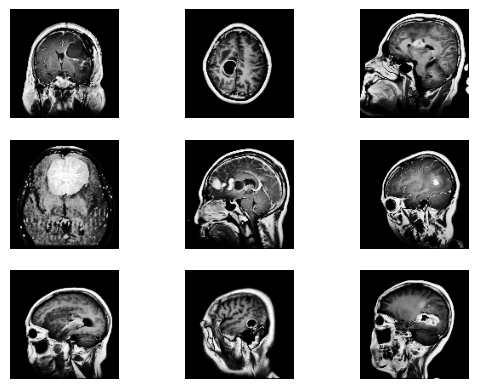

augmented_labels:  690
Glioma_Images:  (690, 128, 128, 3)
Glioma_Labels:  (690,)
---------------- Augmenting ----------------
Generating Images...
the Input data: (749, 128, 128, 3)
Done
690


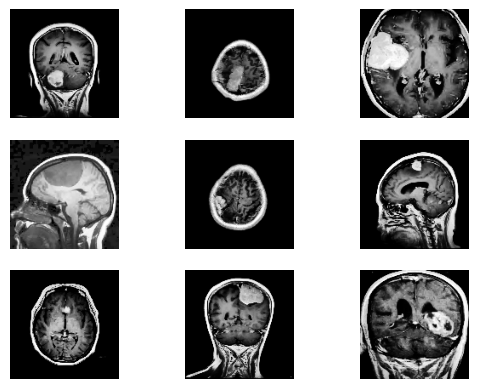

augmented_labels:  690
Menin_Images:  (690, 128, 128, 3)
Menin_Labels:  (690,)
---------------- Augmenting ----------------
Generating Images...
the Input data: (721, 128, 128, 3)
Done
690


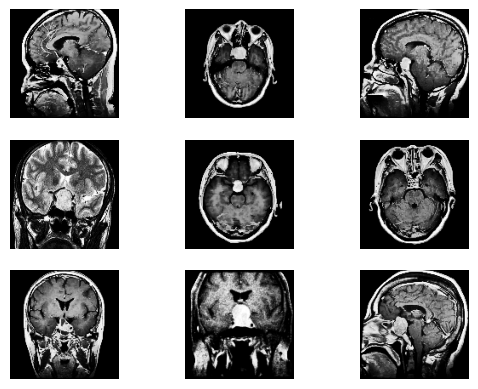

augmented_labels:  690
Pit_Images:  (690, 128, 128, 3)
Pit_Labels:  (690,)
---------------- Mix Up Augmentation ----------------


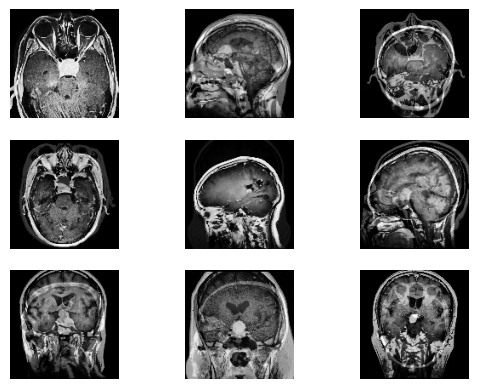

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:24: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751



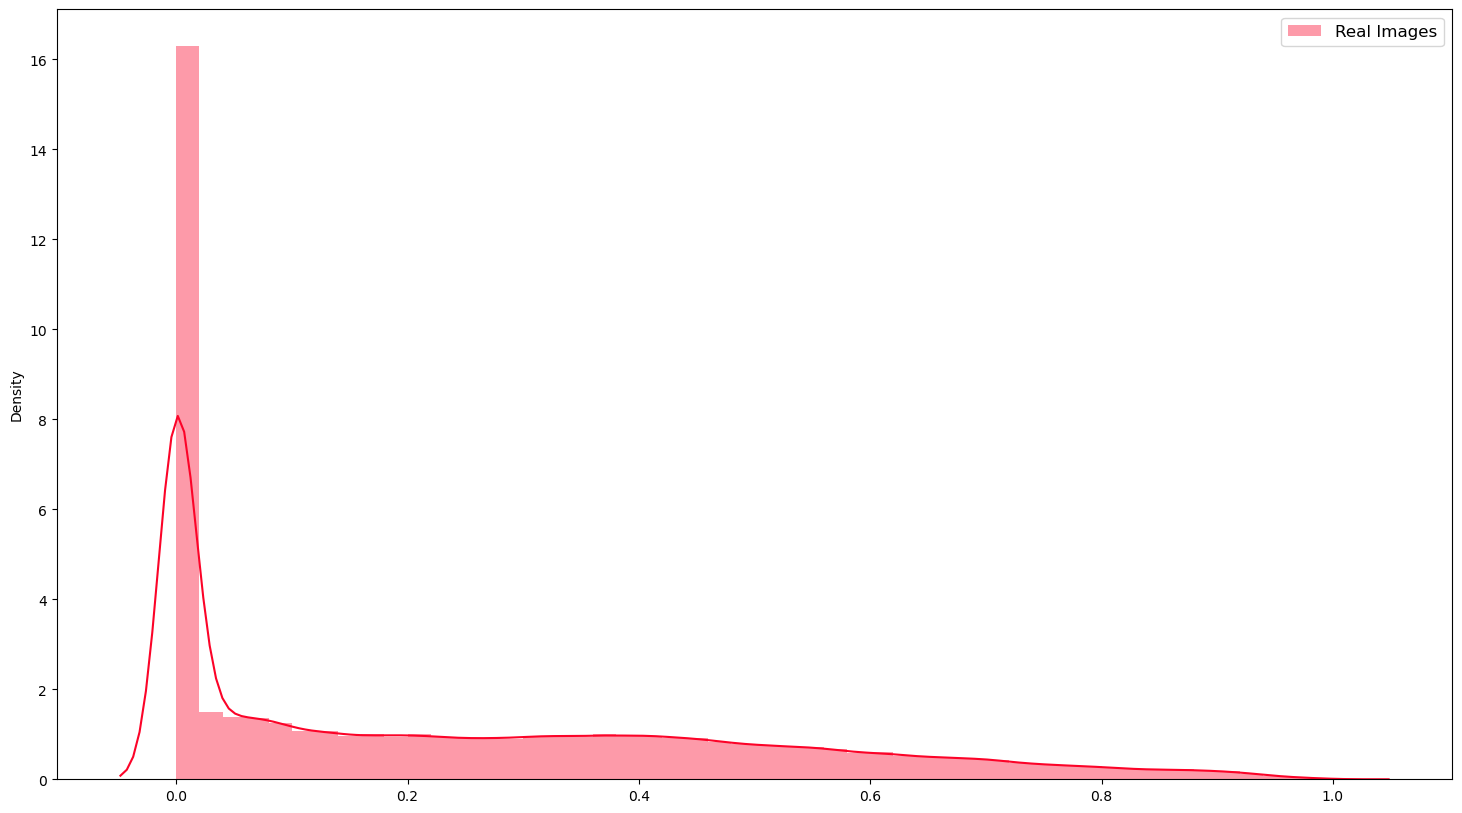

augmented_train_images: (4281, 128, 128, 3), augmented_train_labels: (4281, 3)
Train Images Set After Mixup Augmentation:  (6492, 128, 128, 3)
Train Labels Set After Mixup Augmentation:  (6492, 3)
over


In [20]:
print("Class Distribution before augmentation: ")
def Augmentation_framework(CLASSIC_AUG, GAN_AUG, MIXUP_AUG, Images, Labels, y_val):

    if CLASSIC_AUG == True:
        print("---------------- Classic Augmentation ----------------")
        Glioma_Images, Glioma_Labels= classic_augmentation(data_to_augment[0], label_to_augment[0], 'glioma_tumor')
        print("Glioma_Images: ", Glioma_Images.shape)
        print("Glioma_Labels: ", Glioma_Labels.shape)

        Menin_Images, Menin_Labels= classic_augmentation(data_to_augment[1], label_to_augment[1], 'meningioma_tumor')
        print("Menin_Images: ", Menin_Images.shape)
        print("Menin_Labels: ", Menin_Labels.shape)
        
        Pit_Images, Pit_Labels= classic_augmentation(data_to_augment[2], label_to_augment[2], 'pituitary_tumor')
        print("Pit_Images: ", Pit_Images.shape)
        print("Pit_Labels: ", Pit_Labels.shape)

        # Combine the classically augmented classes to the rest of the x_train
        Images = np.concatenate((Images, Glioma_Images, Menin_Images, Pit_Images ), axis=0)
        Labels = np.concatenate((Labels, Glioma_Labels, Menin_Labels, Pit_Labels), axis=0)


        del Menin_Images
        del Menin_Labels
        del Glioma_Images
        del Glioma_Labels
        del Pit_Images
        del Pit_Labels
        gc.collect()

    if GAN_AUG == True:
        print("---------------- GAN Augmentation ----------------")
        if AUGMENT_MENINGIOMA == True:
            print("--------------- Meningioma Augmentation ---------------")
            generated_images, generated_labels = GAN_Augmentation(Meningioma_generator_dir, 1, AUGMENTATION_RATE, MENINGIOMA_AUGMENTATION_NUM)
            generated_images = np.array(generated_images)
            generated_labels = np.array(generated_labels)

            print(f"Train shape: {x_train.shape}, generated_images shape: {generated_images.shape}")
            Images = np.concatenate((x_train, generated_images), axis=0)
            print("augmented_train_images shape: ", Images.shape)
            print("---------------------------\n")

            print(f"y_train shape: {y_train.shape}, generated_labels shape: {generated_labels.shape}")
            Labels = np.concatenate((y_train, generated_labels), axis=0)
            print("augmented_train_labels shape: ", Labels.shape)

            del x_train
            del y_train
            gc.collect()

        if AUGMENT_PITUITARY == True:
            print("--------------- Pituitary Augmentation ---------------")
            generated_images, generated_labels = GAN_Augmentation(Pituitary_generator_dir, 2, AUGMENTATION_RATE, PITUITARY_AUGMENTATION_NUM)
            generated_images = np.array(generated_images)
            generated_labels = np.array(generated_labels)


            print(f"augmented_train_images shape: { Images.shape}, generated_images shape: {generated_images.shape}")
            Images = np.concatenate((Images, generated_images), axis=0) 
            print("augmented_train_images shape: ", Images.shape)


            print("---------------------------\n")
            print(f"augmented_train_labels shape: {Labels.shape}, generated_labels shape: {generated_labels.shape}")  
            Labels = np.concatenate((Labels, generated_labels), axis=0)
            print("augmented_train_labels shape: ", Labels.shape)

            visualize_class_distribution(Labels, "Post_GAN_Aug")
            np.savetxt(f"{CODE_OUTPUTS}GAN_Aug.csv", Labels, delimiter =", ", fmt ='% s')

    if MIXUP_AUG == True:
        print("---------------- Mix Up Augmentation ----------------")
        mixup_images, mixup_labels = MixUp(Images, Labels)
        print(f"augmented_train_images: {mixup_images.shape}, augmented_train_labels: {mixup_labels.shape}")

        le = LabelEncoder()
        Labels = le.fit_transform(y_train)
        Labels = to_categorical(y_train)


        Images = np.concatenate((x_train, mixup_images), axis=0)
        print("Train Images Set After Mixup Augmentation: ", Images.shape)

        Labels = np.concatenate((Labels, mixup_labels), axis=0)
        print("Train Labels Set After Mixup Augmentation: ", Labels.shape)


        le = LabelEncoder()
        y_val = le.fit_transform(y_val)
        y_val = to_categorical(y_val)

        del mixup_images
        del mixup_labels
        gc.collect()
    
    else:
        le = LabelEncoder()
        Labels = le.fit_transform(Labels)
        Labels = to_categorical(Labels)

        le = LabelEncoder()
        y_val = le.fit_transform(y_val)
        y_val = to_categorical(y_val)
        visualize_distribution(Images, None, 20)
    print("over")

    return Images, Labels, y_val

Images, Labels, y_val = Augmentation_framework(CLASSIC_AUG, GAN_AUG, MIXUP_AUG, x_train, y_train, y_val)
    

# Data generator initialization

In [21]:
def init_data():
    
    train_datagen = ImageDataGenerator()
    val_datagen = ImageDataGenerator()
    test_datagen = ImageDataGenerator()

    train_data = train_datagen.flow(Images,
                                     Labels, 
                                     shuffle= True,
                                     seed= 22, 
                                     batch_size= BATCH_SIZE)
    valid_data = val_datagen.flow(x_val, 
                                   y_val, 
                                   shuffle= True,
                                   seed= 22,
                                   batch_size= BATCH_SIZE)
    test_data = test_datagen.flow(x_test,
                                   y_test,
                                   shuffle= True,
                                   seed= 22,
                                   batch_size= BATCH_SIZE)
    return train_data, valid_data, test_data

# Training

In [22]:
def train():
    config={
    "dropout_1": 0.2,
    "dropout_2": 0.2,        
    "activation_1": "relu",
    "activation_2": "softmax", 
    "optimizer": "adam",
    "decay_rate": 0.9,
    "loss": "categorical_crossentropy", 
    "metric_Acc": "accuracy",
    "epoch": 30,
    "batch_size": 16,
    "nodes": 512,
    "learning_rate": 0.01,
    "layer_num": 2,
    "GAN_Aug": False,
    "Mixup_Aug": True,
    "Classic_Aug": True,
    "tf_model": 'IRV2', 
    "Enhanced": True,
    "Dataset": "Dataset 2",
    'Image_size': 128,
    'Data_Split': '80:20'
    }
    train_data, valid_data, test_data= init_data()
    n_samples_train = len(train_data)*(16)
    print("Training Samples: ", n_samples_train)
    n_samples_val = len(valid_data)*(16)
    print("Validation Samples: ", n_samples_val)
    n_samples_test = len(test_data)*(16)
    print("Test Samples: ", n_samples_test)

        
    def build_transfer_learning_model(base_model):
        print(base_model.layers[-8:])
        for layer in base_model.layers[:-8]:
            layer.trainable = False
        for layer in base_model.layers[-8:]:
            layer.trainable = True


        model = tf.keras.Sequential([
            base_model,
            Flatten(),

            Dense(units=config.nodes, activation= config.activation_1),
            
            Dense(units= config.nodes, activation= config.activation_1),
            
            Dense(units=3, activation=config.activation_2)
        ])

        # Compile the model
        model.compile(
            loss= config.loss,
            optimizer=Adam(config.learning_rate),

            metrics=[config.metric_Acc,
                     TopKCategoricalAccuracy(k= 2, name='Top2_Acc'), 
                     AUC(multi_label= True, num_labels= 3, curve="ROC", name='ROC'), 
                     AUC(multi_label= True, num_labels= 3, curve="PR", name='Precision_Recall'), 
                     Precision(thresholds=0.6), 
                     Recall(thresholds=0.2),
                     TruePositives(), 
                     FalsePositives(), 
                     TrueNegatives(), 
                     FalseNegatives()
                    ])

        return model
    rad_model = build_transfer_learning_model(
    base_model = InceptionResNetV2(weights= model_dir, input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),  include_top=False)
    )
#     tf.keras.utils.plot_model(rad_model, to_file=f"{CODE_OUTPUTS}rad_model+top.png", dpi= 300,  show_shapes=True)

    rad_model.summary()
    callbacks = [WandbMetricsLogger("epoch"),
#                 WandbModelCheckpoint("models"),
                WandbCallback(log_evaluation= True),
#                 EarlyStopping(monitor='val_accuracy', patience=10),
                ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=4, min_lr=0.00001, mode='min'),
                PRMetrics(valid_data, train_data, num_log_batches= 16), 
                csv_logger
                ]
    
    rad_hist = rad_model.fit(
    train_data,
    validation_data= valid_data,
    steps_per_epoch= n_samples_train// config.batch_size,
    validation_steps= n_samples_val// config.batch_size,
    epochs=config.epoch,
    callbacks= callbacks
    
    )

    return rad_model, rad_hist, valid_data, test_data


# Extrac Metrics

In [23]:
class PRMetrics(Callback):
  """ Custom callback to compute per-class PR & ROC curves
  at the end of each training epoch"""
  def __init__(self, generator=None, trainer= None, tester= None, num_log_batches=1):
    self.generator = generator
    self.trainer= trainer
    self.num_batches = num_log_batches
    self.val_f1s = []
    self.val_recalls = []
    self.val_precisions = []
    
    self.class_names= {0: 'glioma_tumor', 1: 'meningioma_tumor', 2: 'pituitary_tumor'}
    self.flat_class_names = ['glioma_tumor', 'meningioma_tumor', 'pituitary_tumor']
    

  def on_epoch_end(self, epoch, logs={}):

    val_data, val_labels = self.generator.next()
    train_data, train_labels = self.trainer.next()
    val_predictions = self.model.predict(val_data)
    print(val_predictions.shape)

    ground_truth_class_ids = val_labels.argmax(axis=1)

    wandb.log({"roc_curve" : wandb.plot.roc_curve(ground_truth_class_ids, val_predictions, labels= self.flat_class_names)})
    wandb.log({"precision_curve" : wandb.plot.pr_curve(ground_truth_class_ids, val_predictions, labels= self.flat_class_names)})
    wandb.log({"precision_recall_curve": wandb.sklearn.plot_precision_recall(ground_truth_class_ids, val_predictions, labels= self.flat_class_names)})

    

# Run Training

In [ ]:
rad_model, rad_hist, valid_data, test_data = train()

wandb: Currently logged in as: fleur. Use `wandb login --relogin` to force relogin


Training Samples:  6496
Validation Samples:  288
Test Samples:  288
[<keras.layers.core.activation.Activation object at 0x71ed5809e710>, <keras.layers.core.activation.Activation object at 0x71ed58061750>, <keras.layers.merging.concatenate.Concatenate object at 0x71ed58069350>, <keras.layers.convolutional.conv2d.Conv2D object at 0x71ed5806d610>, <keras.layers.core.lambda_layer.Lambda object at 0x71ed58076f90>, <keras.layers.convolutional.conv2d.Conv2D object at 0x71ed580bf090>, <keras.layers.normalization.batch_normalization.BatchNormalization object at 0x71ed58003950>, <keras.layers.core.activation.Activation object at 0x71ed5806d190>]
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 inception_resnet_v2 (Functi  (None, 2, 2, 1536)       54336736  
 onal)                                                           
                                                                 
 flatt

wandb: WARNING The save_model argument by default saves the model in the HDF5 format that cannot save custom objects like subclassed models and custom layers. This behavior will be deprecated in a future release in favor of the SavedModel format. Meanwhile, the HDF5 model is saved as W&B files and the SavedModel as W&B Artifacts.
wandb: WARNING WandbCallback is unable to log validation data. When using a generator for validation_data, you must pass validation_steps


Epoch 1/30
406/406 [==============================] - ETA: 0s - loss: 1.4923 - accuracy: 0.7033 - Top2_Acc: 0.9042 - ROC: 0.7332 - Precision_Recall: 0.8925 - precision: 0.9358 - recall: 0.6913 - true_positives: 4306.0000 - false_positives: 363.0000 - true_negatives: 4059.0000 - false_negatives: 10748.0000

wandb: Adding directory to artifact (/kaggle/working/wandb/run-20230425_185726-dkibnfah/files/model-best)... Done. 1.5s


...

1/1 [==============================] - 0s 59ms/step
(16, 3)
406/406 [==============================] - 121s 298ms/step - loss: 0.3922 - accuracy: 0.9536 - Top2_Acc: 0.9988 - ROC: 0.9594 - Precision_Recall: 0.9884 - precision: 0.9998 - recall: 0.5286 - true_positives: 6294.0000 - false_positives: 4.0000 - true_negatives: 4418.0000 - false_negatives: 8760.0000 - val_loss: 0.1562 - val_accuracy: 0.9420 - val_Top2_Acc: 0.9928 - val_ROC: 0.9911 - val_Precision_Recall: 0.9823 - val_precision: 0.9625 - val_recall: 0.9746 - val_true_positives: 259.0000 - val_false_positives: 16.0000 - val_true_negatives: 536.0000 - val_false_negatives: 17.0000 - lr: 0.0020
Epoch 17/30
406/406 [==============================] - ETA: 0s - loss: 0.3858 - accuracy: 0.9600 - Top2_Acc: 0.9997 - ROC: 0.9643 - Precision_Recall: 0.9899 - precision: 1.0000 - recall: 0.5305 - true_positives: 6268.0000 - false_positives: 3.0000 - true_negatives: 4419.0000 - false_negatives: 8786.0000

wandb: Adding directory to artifact (/kaggle/working/wandb/run-20230425_185726-dkibnfah/files/model-best)... Done. 1.4s


1/1 [==============================] - 0s 59ms/step
(16, 3)
406/406 [==============================] - 121s 298ms/step - loss: 0.3858 - accuracy: 0.9600 - Top2_Acc: 0.9997 - ROC: 0.9643 - Precision_Recall: 0.9899 - precision: 1.0000 - recall: 0.5305 - true_positives: 6268.0000 - false_positives: 3.0000 - true_negatives: 4419.0000 - false_negatives: 8786.0000 - val_loss: 0.1467 - val_accuracy: 0.9601 - val_Top2_Acc: 0.9891 - val_ROC: 0.9916 - val_Precision_Recall: 0.9804 - val_precision: 0.9699 - val_recall: 0.9746 - val_true_positives: 263.0000 - val_false_positives: 10.0000 - val_true_negatives: 542.0000 - val_false_negatives: 13.0000 - lr: 0.0020
Epoch 18/30
1/1 [==============================] - 0s 52ms/step- loss: 0.3827 - accuracy: 0.9584 - Top2_Acc: 0.9995 - ROC: 0.9669 - Precision_Recall: 0.9906 - precision: 1.0000 - recall: 0.5310 - true_positives: 6295.0000 - false_positives: 1.0000 - true_negatives: 4421.0000 - false_negatives: 8759.00
(4, 3)
406/406 [========================

wandb: Adding directory to artifact (/kaggle/working/wandb/run-20230425_185726-dkibnfah/files/model-best)... Done. 1.5s


1/1 [==============================] - 0s 63ms/step
(16, 3)
406/406 [==============================] - 120s 295ms/step - loss: 0.3797 - accuracy: 0.9615 - Top2_Acc: 0.9997 - ROC: 0.9697 - Precision_Recall: 0.9914 - precision: 1.0000 - recall: 0.5347 - true_positives: 6302.0000 - false_positives: 3.0000 - true_negatives: 4419.0000 - false_negatives: 8752.0000 - val_loss: 0.1363 - val_accuracy: 0.9565 - val_Top2_Acc: 0.9891 - val_ROC: 0.9924 - val_Precision_Recall: 0.9867 - val_precision: 0.9669 - val_recall: 0.9783 - val_true_positives: 264.0000 - val_false_positives: 12.0000 - val_true_negatives: 540.0000 - val_false_negatives: 12.0000 - lr: 0.0020
Epoch 20/30
1/1 [==============================] - 0s 55ms/step- loss: 0.3779 - accuracy: 0.9654 - Top2_Acc: 1.0000 - ROC: 0.9718 - Precision_Recall: 0.9919 - precision: 0.9998 - recall: 0.5345 - true_positives: 6302.0000 - false_positives: 4.0000 - true_negatives: 4402.0000 - false_negatives: 8720.00
(16, 3)
406/406 [=======================

In [ ]:

# path = "/kaggle/working/"
# saved_model = path + "model_Kaggle_03_84" + "_" + str(config.dropout_1)+ "_" +str(config.dropout_2) + "_"+ str(config.learning_rate) + "_" + str(config.batch_size) + "_" + config.optimizer + ".h5"
# print(saved_model)
# print("Saving: ", saved_model)
# rad_model.save(saved_model)

In [ ]:
# print("Evaluate on test data")

# results = rad_model.evaluate(test_data, batch_size=32)
# print("test loss, test acc:", results)

In [ ]:
# Y_pred = rad_model.predict(test_data, 480 // 32+1)
# y_pred = np.argmax(Y_pred, axis=1)
# print('Confusion Matrix')
# print(confusion_matrix(test_data.classes, y_pred))
# print('Classification Report')
# target_names = ['glioma', 'meningioma', 'pituitary']
# print(classification_report(test_data.classes, y_pred, target_names=target_names))

In [ ]:
plt.plot(rad_hist.history['loss'])
plt.plot(rad_hist.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper right')
plt.show()

In [ ]:
print(rad_hist.history.keys())
# summarize history for accuracy
plt.plot(rad_hist.history['accuracy'])
plt.plot(rad_hist.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='lower right')
plt.show()

In [ ]:
plt.plot(rad_hist.history['precision'])
plt.plot(rad_hist.history['val_precision'])
plt.title('model accuracy')
plt.ylabel('precision')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='lower right')
plt.show()

In [ ]:
plt.plot(rad_hist.history['recall'])
plt.plot(rad_hist.history['val_recall'])
plt.title('model accuracy')
plt.ylabel('precision')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='lower right')
plt.show()

In [ ]:
plt.plot(rad_hist.history['ROC'])
plt.plot(rad_hist.history['val_ROC'])
plt.title('model accuracy')
plt.ylabel('auc')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='lower right')
plt.show()